In [32]:
import string
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

import spacy
nlp = spacy.load('es_core_news_sm', disable=['parser', 'ner'])

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\valde\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\valde\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\valde\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [33]:
df = pd.read_csv('df_total.csv')

TEXT_COL = "news"
CATEGORY_COL = "Type"

print(df.shape)
df.head()

(1217, 3)


,url,news,Type
0,https://www.larepublica.co/redirect/post/3201905,Durante el foro La banca articulador empresari...,Otra
1,https://www.larepublica.co/redirect/post/3210288,El regulador de valores de China dijo el domin...,Regulaciones
2,https://www.larepublica.co/redirect/post/3240676,En una industria históricamente masculina como...,Alianzas
3,https://www.larepublica.co/redirect/post/3342889,Con el dato de marzo el IPC interanual encaden...,Macroeconomia
4,https://www.larepublica.co/redirect/post/3427208,Ayer en Cartagena se dio inicio a la versión n...,Otra


**¿Cuántos documentos tiene el corpus?:** El corpus contiene 1,217 documentos.

**¿Qué columnas contiene y qué información guarda cada una?:** El corpus contiene 3 columnas en donde se guarda el url, texto de la noticia (news) y una etiqueta que hace referencia al tipo de noticia (type).

Type
Macroeconomia     340
Alianzas          247
Innovacion        195
Regulaciones      142
Sostenibilidad    137
Otra              130
Reputacion         26
Name: count, dtype: int64


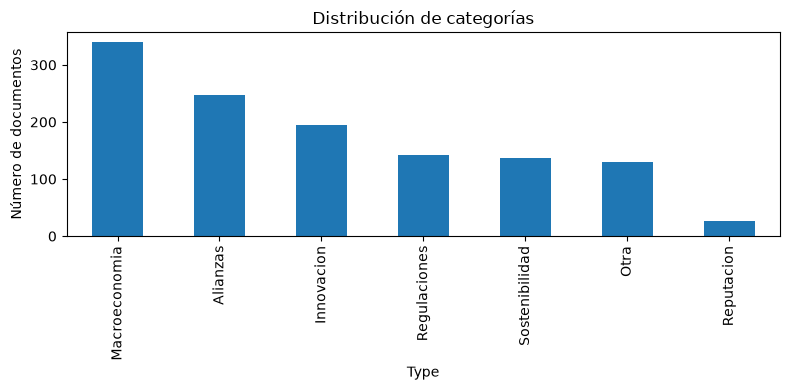

In [34]:
categorias = df[CATEGORY_COL].value_counts()
print(categorias)

categorias.plot(kind='bar', figsize=(8,4), title='Distribución de categorías')
plt.ylabel('Número de documentos')
plt.tight_layout()
plt.show()

**¿Cuántas categorías hay y cómo se distribuyen?:** Existen 7 categorias unicas con la siguiente distribucion:
- Macroeconomia: 27.9%
- Alianzas: 20.3%
- Innovacion: 16.0%
- Regulaciones: 11.7%
- Sostenibilidad: 11.2%
- Otra: 10.7%
- Reputacion: 2.1%

In [35]:
# ¿Hay filas vacías o duplicadas?
print("Valores nulos por columna:")
print(df.isnull().sum())

print("\nFilas completamente duplicadas:", df.duplicated().sum())
print("Textos duplicados:", df.duplicated(subset=[TEXT_COL]).sum())

Valores nulos por columna:
url     0
news    4
Type    0
dtype: int64

Filas completamente duplicadas: 75
Textos duplicados: 79


**¿Hay filas vacías o duplicadas?:** Se identificaron 4 filas con valores nulos en la columna 'news'. Además, existen 75 filas completamente duplicadas y se encontraron 79 registros con contenido duplicado en la columna 'news'.

In [36]:
df = df.dropna(subset=[TEXT_COL]).drop_duplicates(subset=[TEXT_COL]).reset_index(drop=True)
print("Shape final:", df.shape)

Shape final: (1137, 3)


---

In [37]:
def contar_tokens_tipos(columna_de_listas):
    todos = [tok for lista in columna_de_listas for tok in lista]
    return len(todos), len(set(todos))

pasos = []

In [38]:
# i. Tokenización
df['tokens'] = df[TEXT_COL].astype(str).apply(lambda x: word_tokenize(x, language='spanish'))
t, ty = contar_tokens_tipos(df['tokens'])
pasos.append(('Tokenización', t, ty))
print(f"Tokens: {t} | Tipos: {ty}")

Tokens: 631733 | Tipos: 38947


In [39]:
# ii. Minúsculas
df['tokens'] = df['tokens'].apply(lambda toks: [w.lower() for w in toks])
t, ty = contar_tokens_tipos(df['tokens'])
pasos.append(('Minúsculas', t, ty))
print(f"Tokens: {t} | Tipos: {ty}")

Tokens: 631733 | Tipos: 36099


In [40]:
# iii. Eliminar puntuación
puntuacion = set(string.punctuation) | {'¿','¡','—','–','…','“','”','‘','’','»','«'}

def es_puntuacion(tok):
    return all(ch in puntuacion for ch in tok)

df['tokens'] = df['tokens'].apply(lambda toks: [w for w in toks if not es_puntuacion(w)])
t, ty = contar_tokens_tipos(df['tokens'])
pasos.append(('Sin puntuación', t, ty))
print(f"Tokens: {t} | Tipos: {ty}")

Tokens: 598379 | Tipos: 36066


In [41]:
# iv. Eliminar stopwords
stop_es = set(stopwords.words('spanish'))
df['tokens'] = df['tokens'].apply(lambda toks: [w for w in toks if w not in stop_es])
t, ty = contar_tokens_tipos(df['tokens'])
pasos.append(('Sin stopwords', t, ty))
print(f"Tokens: {t} | Tipos: {ty}")

Tokens: 318955 | Tipos: 35855


In [42]:
# v. Lematizar
textos_para_lematizar = df['tokens'].apply(lambda toks: ' '.join(toks))

lemas = []
for doc in nlp.pipe(textos_para_lematizar, batch_size=64):
    lemas.append([t.lemma_.lower() for t in doc if t.lemma_.strip() != ''])

df['tokens'] = lemas
t, ty = contar_tokens_tipos(df['tokens'])
pasos.append(('Lematizado', t, ty))
print(f"Tokens: {t} | Tipos: {ty}")

Tokens: 319421 | Tipos: 28806


In [43]:
pipeline = pd.DataFrame(pasos, columns=['Paso', 'Tokens', 'Tipos'])
pipeline['Tipo/Token'] = (pipeline['Tipos'] / pipeline['Tokens']).round(4)
pipeline

,Paso,Tokens,Tipos,Tipo/Token
0,Tokenización,631733,38947,0.0617
1,Minúsculas,631733,36099,0.0571
2,Sin puntuación,598379,36066,0.0603
3,Sin stopwords,318955,35855,0.1124
4,Lematizado,319421,28806,0.0902


---

EDA del corpus

In [44]:
# Tokens y tipos antes y después de la normalización

tokens_antes, tipos_antes = pasos[0][1], pasos[0][2]
tokens_despues, tipos_despues = pasos[-1][1], pasos[-1][2]

reduccion_vocab = (tipos_antes - tipos_despues) / tipos_antes * 100

print(f"Antes de normalizar   -> Tokens: {tokens_antes} | Tipos: {tipos_antes}")
print(f"Después de normalizar -> Tokens: {tokens_despues} | Tipos: {tipos_despues}")
print(f"Reducción del vocabulario: {reduccion_vocab:.1f}%")

Antes de normalizar   -> Tokens: 631733 | Tipos: 38947
Después de normalizar -> Tokens: 319421 | Tipos: 28806
Reducción del vocabulario: 26.0%


In [45]:
# Riqueza léxica

ttr_global = tipos_despues / tokens_despues
print(f"TTR global: {ttr_global:.4f}")

def ttr_por_categoria(df):
    resultados = {}
    for cat, grupo in df.groupby(CATEGORY_COL):
        todos = [tok for toks in grupo['tokens'] for tok in toks]
        resultados[cat] = len(set(todos)) / len(todos) if len(todos) > 0 else 0
    return pd.Series(resultados).sort_values(ascending=False)

ttr_categoria = ttr_por_categoria(df)
ttr_categoria

TTR global: 0.0902


Reputacion        0.350727
Regulaciones      0.216135
Otra              0.204993
Alianzas          0.203608
Sostenibilidad    0.154691
Innovacion        0.139511
Macroeconomia     0.127567
dtype: float64

In [46]:
# Top 20 palabras más frecuentes

all_tokens = [tok for toks in df['tokens'] for tok in toks]
frecuencias = Counter(all_tokens)

top20 = pd.DataFrame(frecuencias.most_common(20), columns=['Palabra', 'Frecuencia'])
top20

,Palabra,Frecuencia
0,poder,2398
1,bbva,2149
2,año,2022
3,banco,1463
4,país,1397
5,inflación,1348
6,empresa,1295
7,nuevo,1216
8,precio,1199
9,ser,1198


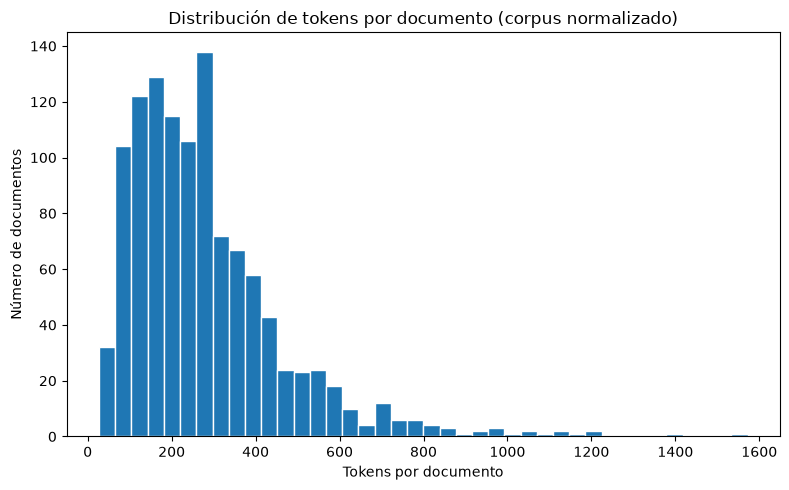

In [47]:
# Histograma de tokens por documento

df['n_tokens'] = df['tokens'].apply(len)

plt.figure(figsize=(8,5))
plt.hist(df['n_tokens'], bins=40, edgecolor='white')
plt.xlabel('Tokens por documento')
plt.ylabel('Número de documentos')
plt.title('Distribución de tokens por documento (corpus normalizado)')
plt.tight_layout()
plt.show()

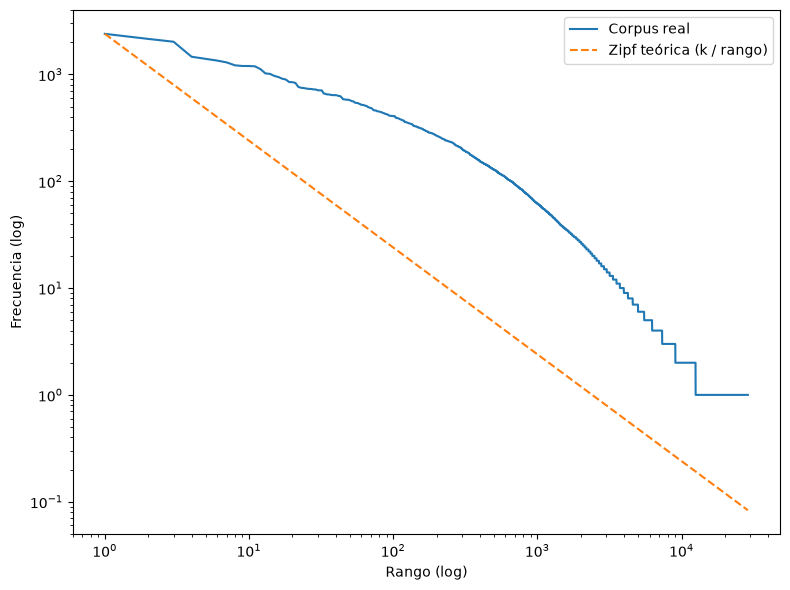

In [48]:
# Ley de Zipf: corpus real vs. curva teórica

frecuencias_ordenadas = np.array([f for _, f in frecuencias.most_common()])
rangos = np.arange(1, len(frecuencias_ordenadas) + 1)

k = frecuencias_ordenadas[0]
zipf_teorica = k / rangos

plt.figure(figsize=(8,6))
plt.loglog(rangos, frecuencias_ordenadas, label='Corpus real')
plt.loglog(rangos, zipf_teorica, linestyle='--', label='Zipf teórica (k / rango)')
plt.xlabel('Rango (log)')
plt.ylabel('Frecuencia (log)')
plt.legend()
plt.tight_layout()
plt.show()

In [49]:
# Comparación por categoría (top 10 palabras mas frecuentes)

categorias_a_comparar = ["Macroeconomia", "Innovacion"]
for cat in categorias_a_comparar:
    tokens_cat = [tok for toks in df[df[CATEGORY_COL] == cat]['tokens'] for tok in toks]
    top10_cat = Counter(tokens_cat).most_common(10)
    print(f"\nTop 10 — {cat}:")
    for palabra, freq in top10_cat:
        print(f"  {palabra}: {freq}")


Top 10 — Macroeconomia:
  inflación: 1278
  precio: 986
  año: 905
  poder: 666
  tasa: 507
  mayor: 507
  bbva: 494
  mes: 489
  país: 430
  aumento: 416

Top 10 — Innovacion:
  bbva: 886
  poder: 496
  banco: 352
  digital: 338
  cliente: 323
  nuevo: 314
  dato: 298
  empresa: 283
  permitir: 259
  financiero: 247


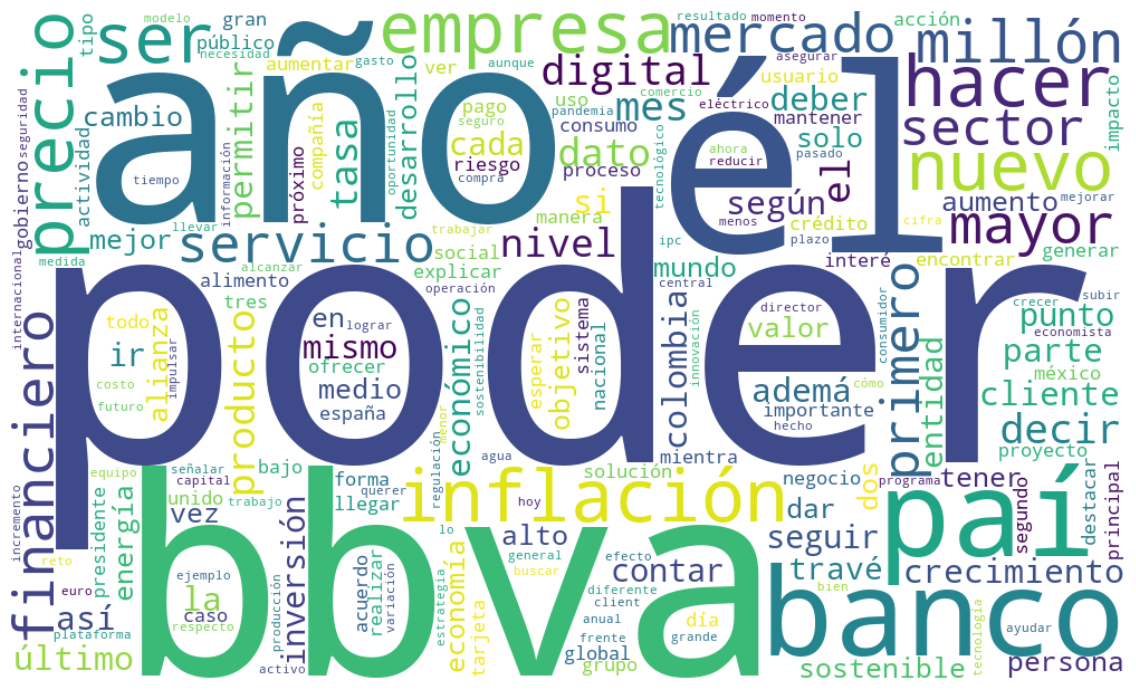

In [50]:
# Nube de palabras del vocabulario normalizado

from wordcloud import WordCloud

texto_completo = ' '.join(all_tokens)
wc = WordCloud(width=1000, height=600, background_color='white', collocations=False).generate(texto_completo)

plt.figure(figsize=(12,7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.tight_layout()
plt.show()

---
---

## Laboratorio 2

#### 1. Bolsa de palabras (Bag of Words)

In [51]:
from sklearn.feature_extraction.text import CountVectorizer

corpus_normalizado = df['tokens'].apply(lambda toks: ' '.join(toks))
vectorizer = CountVectorizer(lowercase=False)

X_bow = vectorizer.fit_transform(corpus_normalizado)

n_docs, vocab_size = X_bow.shape
print(f"Forma de la matriz BoW: {X_bow.shape}")
print(f"Número de documentos: {n_docs}")
print(f"Tamaño del vocabulario: {vocab_size}")

Forma de la matriz BoW: (1137, 23412)
Número de documentos: 1137
Tamaño del vocabulario: 23412


**Explique, con sus propias palabras, qué información se pierde al representar un documento como bolsa de palabras (orden, gramática, contexto) y qué se gana a cambio?**

Cuando se representa un documento como una bolsa de palabras, se tiende a perder el orden de las palabras, la gramática/estructura y el contexto en general de la información original. A cambio, se obtiene una representación numérica y se gana simplicidad y eficiencia para la construcción de modelos y la realización de cómputos rápidos.


---
#### 2. Vectores de conteo y dispersión 

In [52]:
total_celdas = X_bow.shape[0] * X_bow.shape[1]

celdas_no_cero = X_bow.nnz
celdas_cero = total_celdas - celdas_no_cero

sparsity = celdas_cero / total_celdas * 100
print(f"Porcentaje de ceros (sparsity): {sparsity:.2f}%")

Porcentaje de ceros (sparsity): 99.17%


Vocabulario = 100 -> Sparsity: 68.93%
Vocabulario = 500 -> Sparsity: 83.44%
Vocabulario = 1000 -> Sparsity: 88.78%
Vocabulario = 5000 -> Sparsity: 96.64%


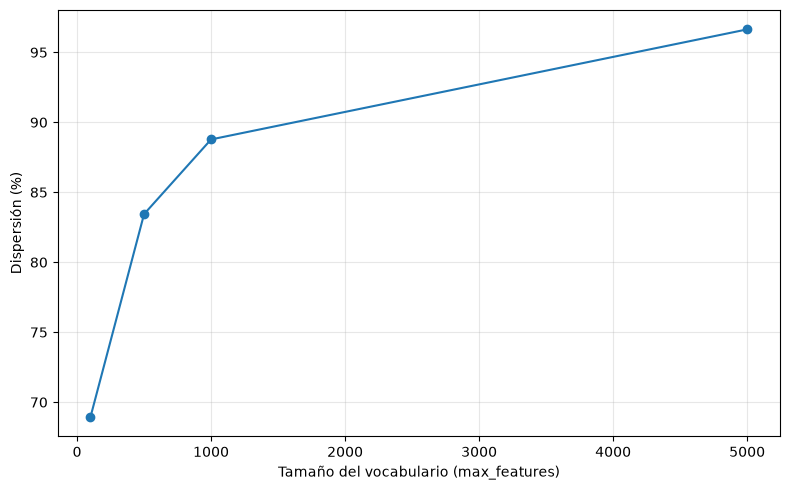

In [53]:
vocab_sizes = [100, 500, 1000, 5000]
sparsities = []

for n in vocab_sizes:
    vec_temp = CountVectorizer(lowercase=False, max_features=n)
    X_temp = vec_temp.fit_transform(corpus_normalizado)
    total = X_temp.shape[0] * X_temp.shape[1]
    sparsity_temp = (total - X_temp.nnz) / total * 100
    sparsities.append(sparsity_temp)
    print(f"Vocabulario = {n} -> Sparsity: {sparsity_temp:.2f}%")

plt.figure(figsize=(8,5))
plt.plot(vocab_sizes, sparsities, marker='o')
plt.xlabel('Tamaño del vocabulario (max_features)')
plt.ylabel('Dispersión (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

- **¿Por qué crece la dispersión al aumentar el vocabulario? ¿Qué implicaciones tiene esto en el costo de almacenamiento y de cómputo?**: La dispercion crece porque cada ves que se aumenta el vocabulario porque se incorporan cada vez palabras mas raras que aparecen en pocos documentos. Esto genera una matriz con cada vez más valores cero, aumentando el espacio de almacenamiento necesario y haciendo que los cálculos sean más costosos y lentos.

- **¿Qué es una matriz dispersa (sparse matrix)? ¿Por qué se usan estructuras especiales (p. ej. formato CSR) en vez de matrices densas para este tipo de datos?**: Una matriz dispersa es una matriz donde la mayoria de los elementos son cero. Se utilizan estructuras especiales, como la del formato CSR, porque permiten almacenar unicamente los valores que son diferentes a 0 y sus pocisiones. Esto permite reducir el espacio de almacenamiento necesario y hacer calculos mas eficientes.

---
#### 3. N-gramas

In [54]:
# Unigramas
vectorizer_uni = CountVectorizer(lowercase=False, ngram_range=(1, 1))
X_uni = vectorizer_uni.fit_transform(corpus_normalizado)

# Bigramas
vectorizer_bi = CountVectorizer(lowercase=False, ngram_range=(2, 2))
X_bi = vectorizer_bi.fit_transform(corpus_normalizado)

print(f"Vocabulario unigramas: {X_uni.shape[1]}")
print(f"Vocabulario bigramas:  {X_bi.shape[1]}")

Vocabulario unigramas: 23412
Vocabulario bigramas:  227574


In [55]:
frecuencias_bi = np.asarray(X_bi.sum(axis=0)).flatten()
vocab_bi = vectorizer_bi.get_feature_names_out()

top_idx = np.argsort(frecuencias_bi)[::-1][:15]
top_bigramas = pd.DataFrame({
    'Bigrama': vocab_bi[top_idx],
    'Frecuencia': frecuencias_bi[top_idx]
})

top_bigramas

,Bigrama,Frecuencia
0,banco central,219
1,poder ser,201
2,bbva research,200
3,tasa interés,189
4,cada vez,184
5,entidad financiero,160
6,cambio climático,157
7,punto básico,139
8,año pasado,136
9,bbva méxico,134


- **¿Los bigramas aportan informacion que los unigramas (por si solos) no capturan?**: Algunos bigramas (como los de 'banco central', 'tasa interés', 'cambio climatica') si ofrecen mas informacion ya que capturan de mejor manera algunas relaciones semanticas que los unigramas pierden por ambiguedad.

- **¿Qué ventaja ofrecen los bigramas/trigramas frente a la bolsa de palabras clásica (unigramas)? ¿Qué costo tienen en tamaño de vocabulario?**: Los bigramas/trigramas caputran relaciones de contexto local y ayudan a reducir la ambiguedad que algunos terminos pierden al estar sueltas. El costo es un crecimiento rapido del tamaño de vocabulario, lo que lleva a una mayor dispercion en la matriz y un mayor costo de almacenamiento y computo.

---
#### 4. TF-IDF

In [56]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(lowercase=False)
X_tfidf = tfidf_vectorizer.fit_transform(corpus_normalizado)

print(f"Shape TF-IDF: {X_tfidf.shape}")

Shape TF-IDF: (1137, 23412)


In [57]:
categorias_unicas = df[CATEGORY_COL].unique()

cats_elegidas = ["Macroeconomia", "Alianzas", "Innovacion"]
docs_idx = [df[df[CATEGORY_COL] == cat].index[0] for cat in cats_elegidas]

vocab_tfidf = tfidf_vectorizer.get_feature_names_out()

print("Top 10 palabras con mayor puntaje TF-IDF")
for idx, cat in zip(docs_idx, cats_elegidas):
    fila_tfidf = X_tfidf[idx].toarray().flatten()
    top10_idx = np.argsort(fila_tfidf)[::-1][:10]
    
    print(f"\nDocumento {idx} ({cat})")
    for i in top10_idx:
        print(f"- {vocab_tfidf[i]}: {fila_tfidf[i]:.4f}")

Top 10 palabras con mayor puntaje TF-IDF

Documento 3 (Macroeconomia)
- marzo: 0.2567
- ipc: 0.2363
- tasa: 0.2244
- mensual: 0.1901
- situar: 0.1615
- 95: 0.1602
- ipca: 0.1538
- punto: 0.1498
- pescado: 0.1384
- interanual: 0.1316

Documento 2 (Alianzas)
- viva: 0.3193
- aerolínea: 0.2467
- aerobus: 0.1968
- us50: 0.1782
- aviación: 0.1632
- low: 0.1488
- cost: 0.1428
- avión: 0.1379
- pasajero: 0.1365
- vivo: 0.1338

Documento 7 (Innovacion)
- agile: 0.4218
- nacho: 0.3307
- podcast: 0.2674
- alumno: 0.2629
- introducir: 0.2087
- legal: 0.1857
- thinktank: 0.1653
- nachir: 0.1653
- rrhh: 0.1653
- bondades: 0.1653


**¿Qué valor juegan estas palabras dentro de los artículos y como refleja su puntaje este papel?**

Estas palabras funcionan como etiquetas que ayudan a identificar de qué trata cada artículo. El puntaje refleja qué tan frecuente es una palabra dentro del documento y qué tan común es en relación con el resto del corpus. Mientras más alto sea el puntaje, más exclusiva y representativa es esa palabra de ese artículo en particular.

In [58]:
vocab_bow = vectorizer.get_feature_names_out()

print("Top 10 palabras mas frecuentes (conteo simple)")
for idx, cat in zip(docs_idx, cats_elegidas):
    fila_conteo = X_bow[idx].toarray().flatten()
    top10_idx = np.argsort(fila_conteo)[::-1][:10]
    
    print(f"\nDocumento {idx} ({cat})")
    for i in top10_idx:
        print(f"- {vocab_bow[i]}: {fila_conteo[i]}")

Top 10 palabras mas frecuentes (conteo simple)

Documento 3 (Macroeconomia)
- tasa: 8
- ipc: 7
- marzo: 7
- punto: 6
- mensual: 5
- situar: 4
- precio: 4
- impuesto: 3
- febrero: 3
- inflación: 3

Documento 2 (Alianzas)
- viva: 4
- año: 4
- aerolínea: 4
- modelo: 3
- trabajar: 3
- bajo: 3
- promedio: 2
- precio: 2
- ser: 2
- low: 2

Documento 7 (Innovacion)
- podcast: 3
- agile: 3
- sector: 2
- legal: 2
- varios: 2
- introducir: 2
- nacho: 2
- alumno: 2
- organización: 1
- publicación: 1


**¿Las 10 palabras con mayor puntaje TF-IDF coinciden con las 10 palabras más frecuentes (por conteo simple) de los mismos documentos? ¿Qué diferencias observa y por qué ocurren, según las fórmulas de TF e IDF vistas en clase?**

No coinciden completamente. Aunque algunas palabras aparecen en ambas listas, otras palabras tienen un puntaje TF-IDF alto aunque no sean las más frecuentes. Esto pasas porque el TF considera qué tan frecuente es una palabra dentro del documento, mientras que el IDF reduce el peso de las palabras que aparecen en muchos documentos del corpus.

**¿Por que es que TF-IDF penaliza palabras muy comunes en todo el corpus y favorece palabras raras pero repetidas dentro de un documento?**

TF-IDF penaliza las palabras comunes porque su valor IDF disminuye cuando una palabra aparece en muchos documentos. Una palabra que aparece varias veces en un documento pero en pocos documentos del corpus tiende a obtener un valor TF alto y un valor IDF alto.

---
#### 5. Similitud entre documentos (similitud coseno)

In [59]:
from sklearn.metrics.pairwise import cosine_similarity

sim_matrix = cosine_similarity(X_tfidf)
print(f"Shape matriz de similitud: {sim_matrix.shape}")

Shape matriz de similitud: (1137, 1137)


In [60]:
doc_ref_idx = 0
# doc_ref_idx = 3

cat_ref = df.loc[doc_ref_idx, CATEGORY_COL]

similitudes = sim_matrix[doc_ref_idx]

similitudes_sin_self = similitudes.copy()
similitudes_sin_self[doc_ref_idx] = -1

top5_idx = np.argsort(similitudes_sin_self)[::-1][:5]

print(f"Documento {doc_ref_idx} ({cat_ref})\n")

print("Documentos más similares:")
for i in top5_idx:
    print(f"- Doc {i} | Categoría: {df.loc[i, CATEGORY_COL]} | Similitud: {similitudes_sin_self[i]:.4f}")

coincidencias = sum(df.loc[i, CATEGORY_COL] == cat_ref for i in top5_idx)
print(f"\nCoincidencias de categoría: {coincidencias}/5")

Documento 0 (Otra)

Documentos más similares:
- Doc 544 | Categoría: Otra | Similitud: 0.3179
- Doc 1026 | Categoría: Sostenibilidad | Similitud: 0.2382
- Doc 1007 | Categoría: Otra | Similitud: 0.2201
- Doc 546 | Categoría: Sostenibilidad | Similitud: 0.2190
- Doc 858 | Categoría: Sostenibilidad | Similitud: 0.2149

Coincidencias de categoría: 2/5


In [61]:
cats_unicas = sorted(df[CATEGORY_COL].unique())
sim_por_categoria = pd.DataFrame(index=cats_unicas, columns=cats_unicas, dtype=float)

for c1 in cats_unicas:
    for c2 in cats_unicas:
        idx1 = df[df[CATEGORY_COL] == c1].index.values
        idx2 = df[df[CATEGORY_COL] == c2].index.values
        bloque = sim_matrix[np.ix_(idx1, idx2)]
        if c1 == c2:
            mask = ~np.eye(bloque.shape[0], dtype=bool)
            sim_por_categoria.loc[c1, c2] = bloque[mask].mean()
        else:
            sim_por_categoria.loc[c1, c2] = bloque.mean()

sim_por_categoria

,Alianzas,Innovacion,Macroeconomia,Otra,Regulaciones,Reputacion,Sostenibilidad
Alianzas,0.039230,0.037251,0.031905,0.038434,0.035257,0.038162,0.034263
Innovacion,0.037251,0.083087,0.040039,0.057978,0.040647,0.044000,0.052692
Macroeconomia,0.031905,0.040039,0.097142,0.051043,0.039944,0.042465,0.040799
Otra,0.038434,0.057978,0.051043,0.078553,0.040031,0.044213,0.048422
Regulaciones,0.035257,0.040647,0.039944,0.040031,0.054414,0.042090,0.036445
Reputacion,0.038162,0.044000,0.042465,0.044213,0.042090,0.119956,0.041545
Sostenibilidad,0.034263,0.052692,0.040799,0.048422,0.036445,0.041545,0.076958


**Explique ¿por qué se usa similitud coseno en lugar de distancia euclidiana para comparar documentos de distinta longitud?**

Se usa la similitud coseno porque mide el ángulo entre los vectores en vez de su magnitud. Esto significa que compara la proporción relativa de palabras sin verse afectada por la longitud del documento a diferencia de lla distancia euclidiana, que sí depende de la magnitud y por lo tanto termina penalizando a documentos largos aunque traten el mismo tema que uno corto.

---
---

## Laboratorio 3

#### 1. Conjuntos de entrenamiento, validación y prueba

In [67]:
from sklearn.model_selection import train_test_split

X = corpus_normalizado
y = df[CATEGORY_COL]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

print("Número de documentos por conjunto:")
print(f"- Entrenamiento: {len(y_train)}")
print(f"- Validación:    {len(y_val)}")
print(f"- Prueba:        {len(y_test)}")
print(f"- Total:         {len(y_train) + len(y_val) + len(y_test)}")

Número de documentos por conjunto:
- Entrenamiento: 795
- Validación:    171
- Prueba:        171
- Total:         1137


In [69]:
conteos = pd.DataFrame({
    'Entrenamiento': y_train.value_counts(),
    'Validación': y_val.value_counts(),
    'Prueba': y_test.value_counts(),
}).fillna(0).astype(int)

conteos

,Entrenamiento,Validación,Prueba
Type,,,
Alianzas,172,37,37
Innovacion,106,23,23
Macroeconomia,223,48,48
Otra,90,19,20
Regulaciones,99,21,21
Reputacion,18,4,4
Sostenibilidad,87,19,18


In [70]:
proporciones = pd.DataFrame({
    'Entrenamiento': y_train.value_counts(normalize=True),
    'Validación': y_val.value_counts(normalize=True),
    'Prueba': y_test.value_counts(normalize=True),
}).fillna(0).round(4)

proporciones

,Entrenamiento,Validación,Prueba
Type,,,
Alianzas,0.2164,0.2164,0.2164
Innovacion,0.1333,0.1345,0.1345
Macroeconomia,0.2805,0.2807,0.2807
Otra,0.1132,0.1111,0.1170
Regulaciones,0.1245,0.1228,0.1228
Reputacion,0.0226,0.0234,0.0234
Sostenibilidad,0.1094,0.1111,0.1053


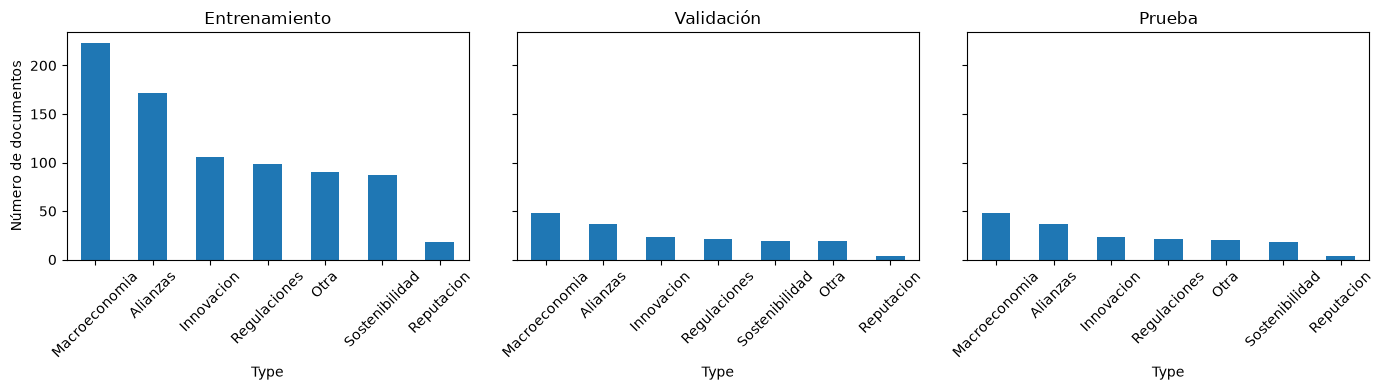

In [71]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, (nombre, etiquetas) in zip(
    axes,
    [('Entrenamiento', y_train), ('Validación', y_val), ('Prueba', y_test)]
):
    etiquetas.value_counts().plot(kind='bar', ax=ax, title=nombre)
    ax.set_ylabel('Número de documentos')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Explique con sus propias palabras para qué sirve cada conjunto (entrenamiento, validación, prueba) y por qué no se debe usar el conjunto de prueba para tomar decisiones durante el desarrollo del modelo.**

Los conjuntos de entrenamiento, validación y prueba tienen diferentes objetivos. El conjunto de entrenamiento se utiliza para que el modelo pueda aprender los patrones presentes en el corpus. Por otro lado, el conjunto de validación se utiliza para comparar modelos, ajustar hiperparámetros o decidir cuándo detener el entrenamiento, por ejemplo, para evitar el sobreajuste. Por último, el conjunto de prueba se utiliza únicamente para medir qué tan bien generaliza el modelo cuando se le presentan datos que nunca ha visto. Este conjunto no debe utilizarse para tomar decisiones durante el desarrollo del modelo, ya que esto haría que dejara de ser una medida confiable de su capacidad de generalización. En ese caso, terminaría funcionando como un segundo conjunto de validación, sobre el cual también podría producirse un sobreajuste de manera involuntaria.

---

#### 2. Construcción del clasificador Naive Bayes

In [72]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

bow_vectorizer = CountVectorizer(lowercase=False)
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_val_bow = bow_vectorizer.transform(X_val)
X_test_bow = bow_vectorizer.transform(X_test)

nb_bow = MultinomialNB()
nb_bow.fit(X_train_bow, y_train)

print("Modelo Naive Bayes (Bolsa de Palabras) entrenado.")
print(f"  Vocabulario: {len(bow_vectorizer.get_feature_names_out())} palabras")
print(f"  Categorías: {list(nb_bow.classes_)}")

Modelo Naive Bayes (Bolsa de Palabras) entrenado.
  Vocabulario: 19039 palabras
  Categorías: [np.str_('Alianzas'), np.str_('Innovacion'), np.str_('Macroeconomia'), np.str_('Otra'), np.str_('Regulaciones'), np.str_('Reputacion'), np.str_('Sostenibilidad')]


In [73]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer_train = TfidfVectorizer(lowercase=False)
X_train_tfidf = tfidf_vectorizer_train.fit_transform(X_train)
X_val_tfidf = tfidf_vectorizer_train.transform(X_val)
X_test_tfidf = tfidf_vectorizer_train.transform(X_test)

nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train)

print("Modelo Naive Bayes (TF-IDF) entrenado.")
print(f"  Vocabulario: {len(tfidf_vectorizer_train.get_feature_names_out())} palabras")
print(f"  Categorías: {list(nb_tfidf.classes_)}")

Modelo Naive Bayes (TF-IDF) entrenado.
  Vocabulario: 19039 palabras
  Categorías: [np.str_('Alianzas'), np.str_('Innovacion'), np.str_('Macroeconomia'), np.str_('Otra'), np.str_('Regulaciones'), np.str_('Reputacion'), np.str_('Sostenibilidad')]


**Explique, con sus propias palabras y apoyándose en el teorema de Bayes visto en clase, qué representan P(c) y P(wᵢ|c) en el contexto de este corpus de noticias, y cómo el modelo combina ambas probabilidades para clasificar un documento nuevo.**

P(c) es la probabilidad a priori de una categoría. Basicamente es qué tan frecuente es esa categoría dentro del conjunto de entrenamiento, sin tomar en cuenta el contenido del documento. P(wᵢ|c), por otro lado, es la probabilidad de observar una palabra específica (wᵢ) dado que el documento pertenece a la categoría c, se estima a partir de qué tan seguido aparece esa palabra en los documentos de entrenamiento de esa categoría en particular. Para clasificar un documento nuevo, el modelo aplica el teorema de Bayes en donde P(c|documento) es proporcional a P(c) multiplicado por el producto de P(wᵢ|c) de todas las palabras del documento. Combina qué tan probable es la categoría de antemano con qué tan probable es observar cada una de las palabras del documento si se asume que pertenece a esa categoría, asumiendo que las palabras son independientes entre sí. Este cálculo se repite para cada categoría posible, y el modelo asigna al documento la categoría que obtiene la probabilidad más alta.